## Boundray point VAE

In [1]:
import torch

from models.BPResVAE import BPResVAE
from utils.load_bp import load_from_dir

from matplotlib import pyplot as plt
from utils.generate import generate_data
from utils.visualize import contour_to_binary, contour_to_scatter, make_grid, visualize_latent_space
import torch.utils.tensorboard
from train import train_vae

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
IMAGE_DIR = "data/img/BW bird"
TB_PATH = "runs/BPResVAE_bird"
TB_COMMENT = ''
MODEL_LOAD_PATH = 'runs/BPResVAE_bird/4/model.pth'
SEED = 717

INPUT_DIM = 200  # Adjusted input dimension to match your complex data
H_DIM = 1000
Z_DIM = 2
H_LAYERS = [2, 2, 2]

NUM_EPOCHS = 100000
BATCH_SIZE = 32  # Adjusted batch size
LR_RATE = 1e-5  # smaller learning rate
KL_RATE = 0.25

input_np = load_from_dir(IMAGE_DIR, 100, 25)
input_tensor = torch.tensor(input_np).to(dtype=torch.float64)

Loading BW1.jpg
Loading BW10.jpg
Loading BW11.jpg
Loading BW12.jpg
Loading BW13.jpg
Loading BW15.jpg
Loading BW16.jpg
Loading BW17.jpg
Loading BW18.jpg
Loading BW19.jpg
Loading BW2.jpg
Loading BW20.jpg
Loading BW21.jpg
Loading BW22.jpg
Loading BW23.jpg
Loading BW24.jpg
Loading BW25.jpg
Loading BW3.jpg
Loading BW4.jpg
Loading BW5.jpg
Loading BW6.jpg
Loading BW7.jpg
Loading BW8.jpg
Loading BW9.jpg


In [17]:
model = BPResVAE(
    input_dim=INPUT_DIM,
    hidden_dim=H_DIM,
    hidden_layers=H_LAYERS,
    latent_dim=Z_DIM,
    device=DEVICE,
)

model, _ = train_vae(
    model=model,
    input_tensor=input_tensor,
    input_dim=INPUT_DIM,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR_RATE,
    kl_rate=KL_RATE,
    device=DEVICE,
    tb_path=TB_PATH,
    tb_comment=TB_COMMENT,
    # model_load_path=MODEL_LOAD_PATH,
    seed=SEED,
    dtype=torch.float64,
    # skip_train=True,
)

train index: tensor([ 0, 14,  4,  2,  7, 22, 15,  6, 10, 16, 23,  5,  9, 20,  8,  1, 18, 11,
        21, 12, 13, 17, 19,  3])
val index: tensor([], dtype=torch.int64)
Best epoch 0/100000 | loss: 419.5872, recon_loss: 414.5194, kl_loss: 20.2713
Epoch 0/100000 | loss: 419.5872, recon_loss: 414.5194, kl_loss: 20.2713
Best epoch 1/100000 | loss: 347.6175, recon_loss: 343.6793, kl_loss: 15.7529
Best epoch 2/100000 | loss: 294.9680, recon_loss: 291.6727, kl_loss: 13.1811
Best epoch 3/100000 | loss: 265.6043, recon_loss: 262.5210, kl_loss: 12.3328
Best epoch 4/100000 | loss: 215.8064, recon_loss: 211.6700, kl_loss: 16.5453
Best epoch 5/100000 | loss: 172.5133, recon_loss: 167.9104, kl_loss: 18.4115
Best epoch 6/100000 | loss: 163.1529, recon_loss: 158.5333, kl_loss: 18.4783
Best epoch 7/100000 | loss: 133.0534, recon_loss: 128.1763, kl_loss: 19.5086
Best epoch 8/100000 | loss: 115.4818, recon_loss: 110.4647, kl_loss: 20.0686
Best epoch 9/100000 | loss: 86.8921, recon_loss: 81.4783, kl_loss: 2

Encode-decode

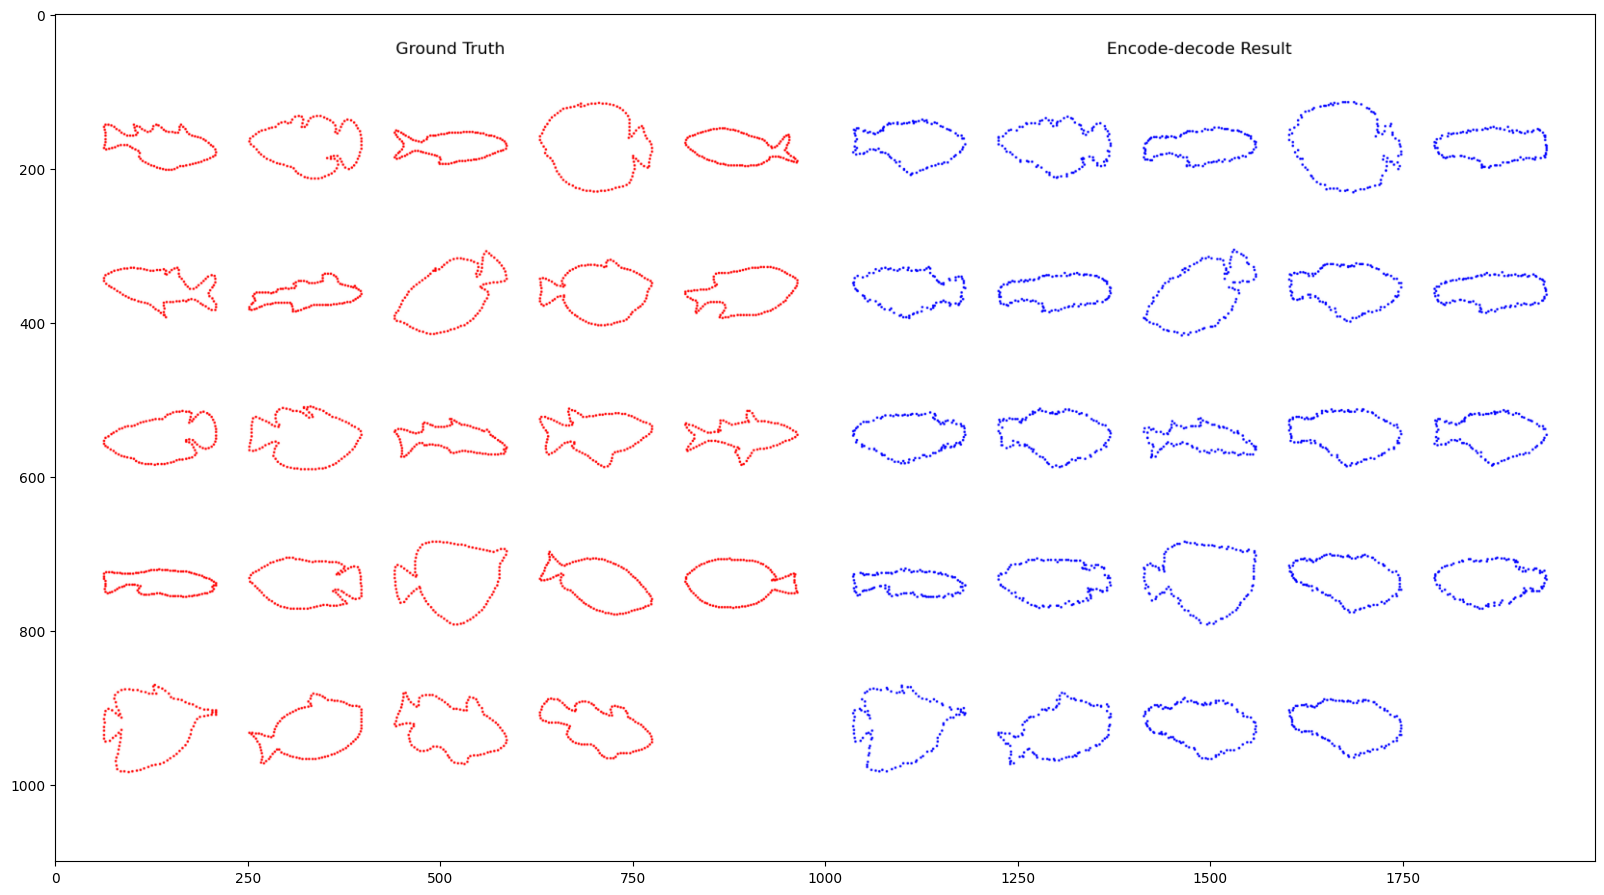

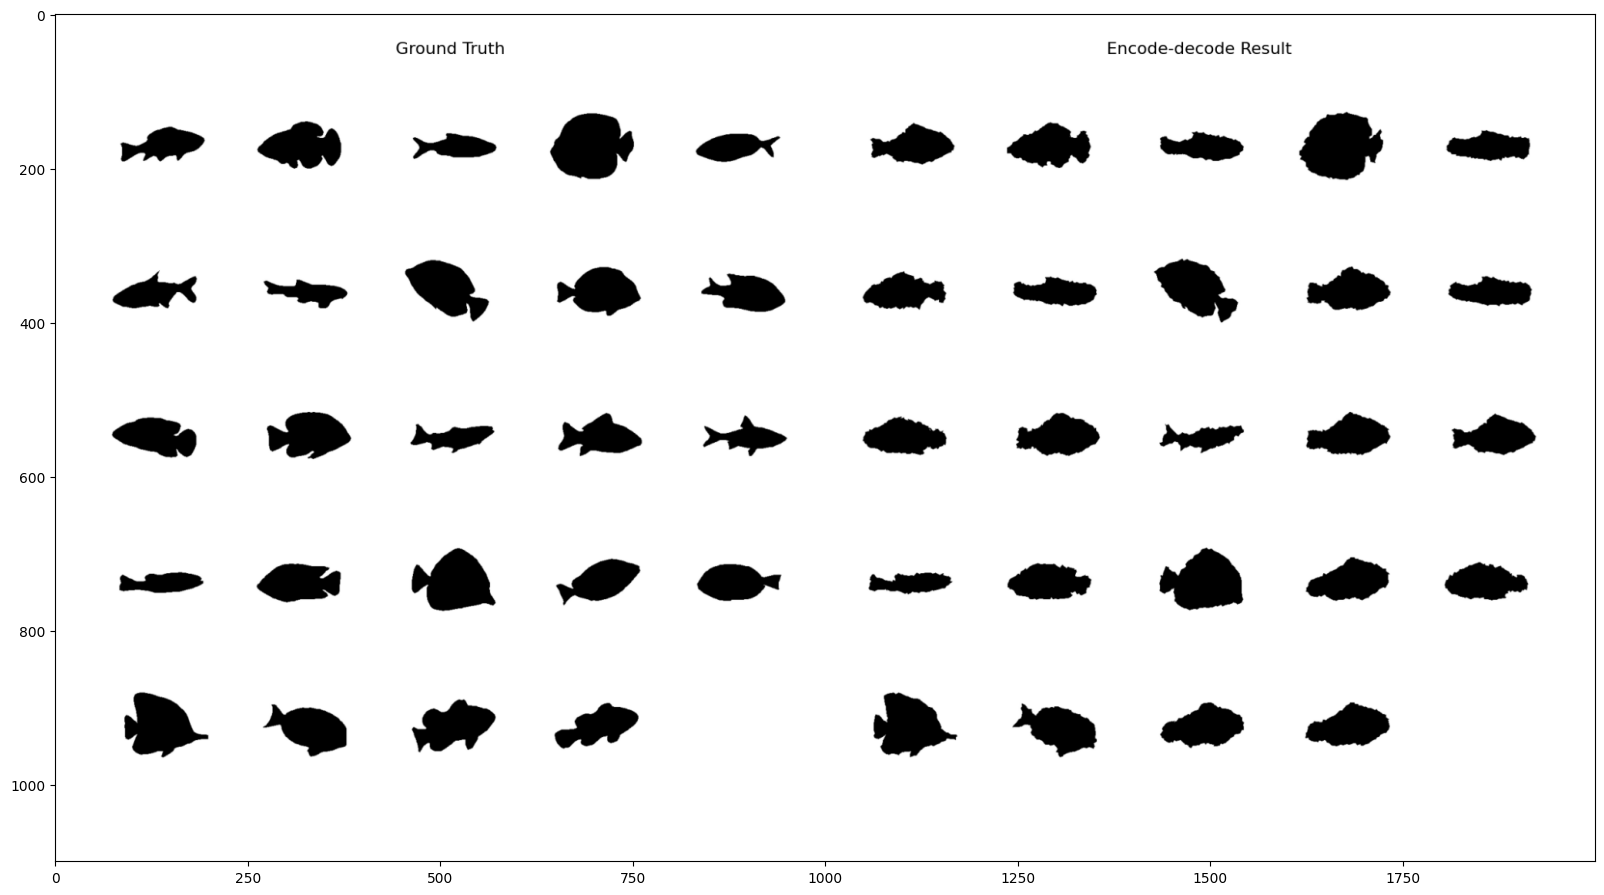

In [18]:
# model = model[0]
n = input_tensor.shape[0]
generated_contour, _, _ = model(
    input_tensor.to(DEVICE, dtype=torch.float64).view(n, INPUT_DIM), 0
)
generated_contour = generated_contour.cpu().detach()
generated_contour = model.reconstruct(generated_contour).numpy()

ground_truth_contour = input_tensor.cpu().numpy()

generated_images = [
    contour_to_scatter(contour, color='b', figsize=(2,2), pointsize=2) for contour in generated_contour
]
ground_truth_images = [
    contour_to_scatter(contour, color='r', figsize=(2,2), pointsize=2) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10,11))
generated_grid = make_grid(generated_images, rows=5, title="Encode-decode Result", figsize=(10,11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20,11))
plt.figure(figsize=(20, 11))
plt.imshow(combined_grid)
# plt.imsave()

generated_images = [
    contour_to_binary(contour, rate=0.65) for contour in generated_contour
]
ground_truth_images = [
    contour_to_binary(contour, rate=0.65) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title="Encode-decode Result", figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 11))
plt.imshow(combined_grid)
plt.show()

Random Generation

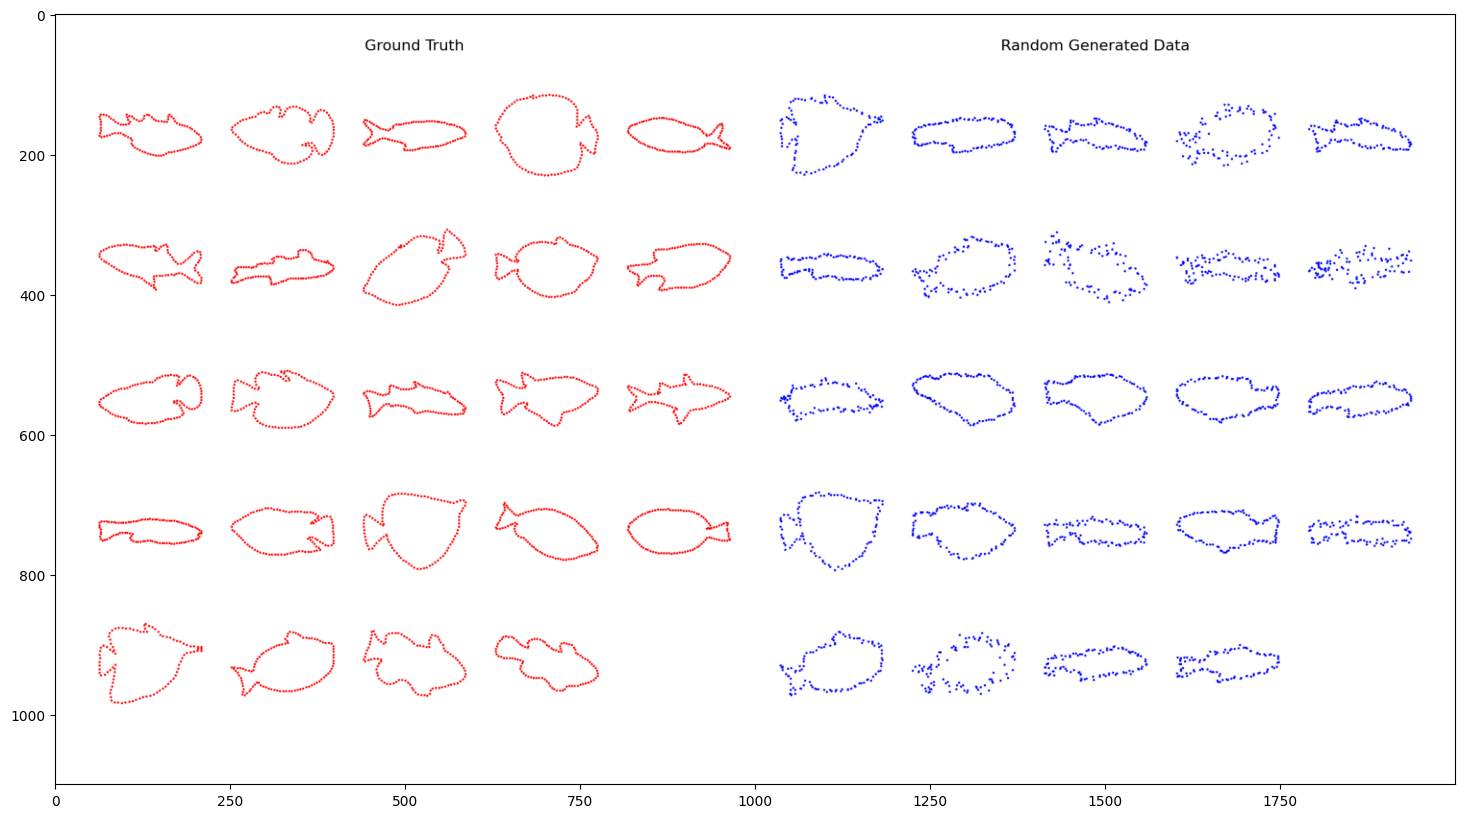

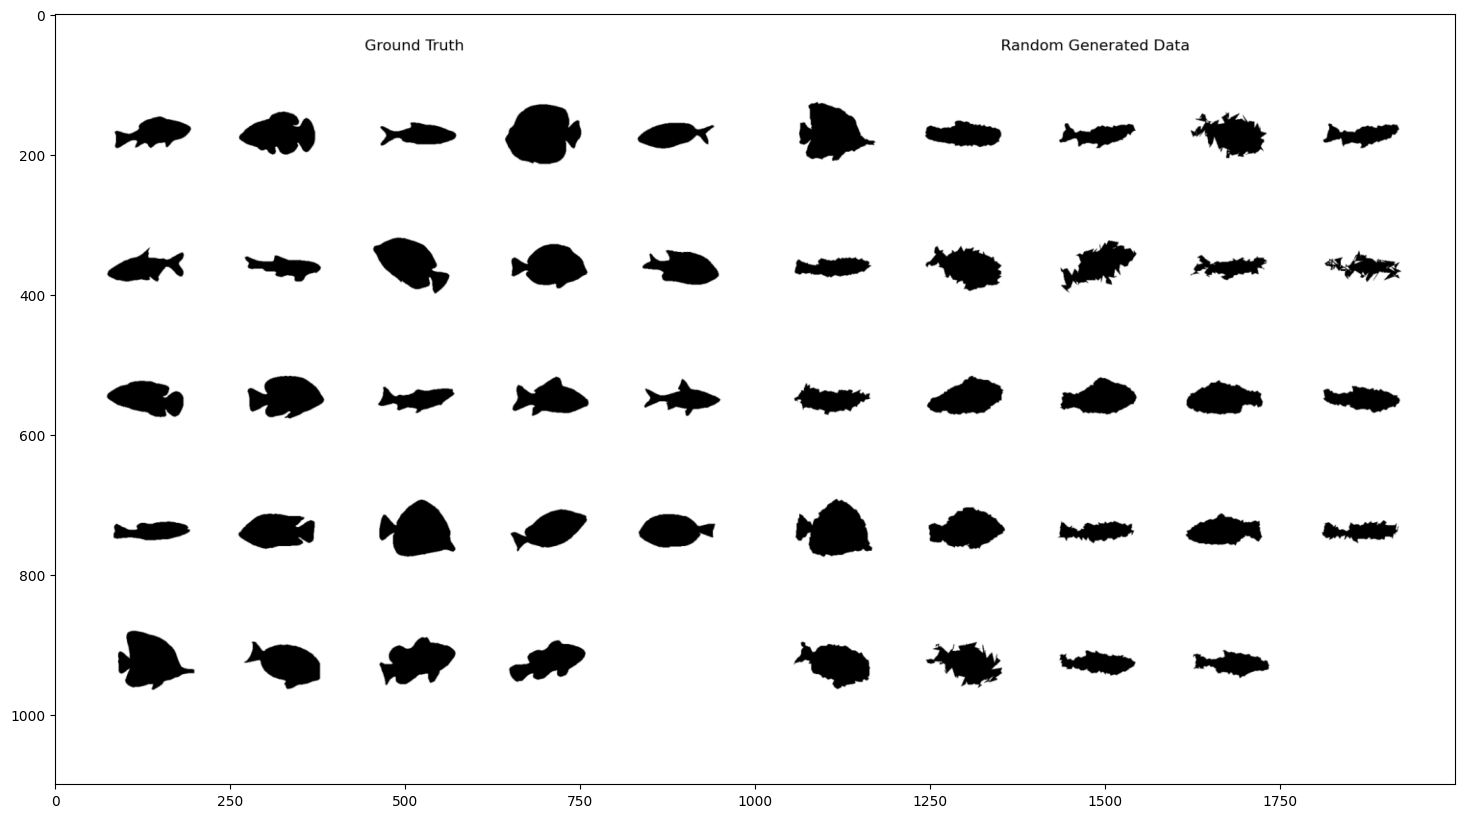

In [19]:
n = input_tensor.shape[0]
generated_contour, _ = generate_data(model, num=n, k=2)
generated_contour = model.reconstruct(generated_contour).numpy()

ground_truth_contour = input_tensor.cpu().numpy()

generated_images = [
    contour_to_scatter(contour, color='b', figsize=(2,2), pointsize=2) for contour in generated_contour
]
ground_truth_images = [
    contour_to_scatter(contour, color='r', figsize=(2,2), pointsize=2) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title="Random Generated Data", figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 10))
plt.imshow(combined_grid)

generated_images = [
    contour_to_binary(contour, rate=0.65) for contour in generated_contour
]
ground_truth_images = [
    contour_to_binary(contour, rate=0.65) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title="Random Generated Data", figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 10))
plt.imshow(combined_grid)

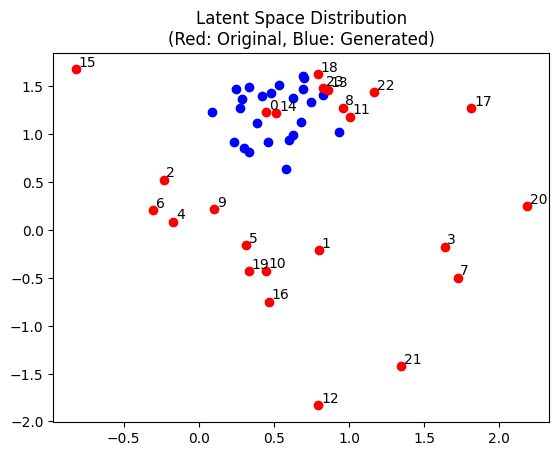

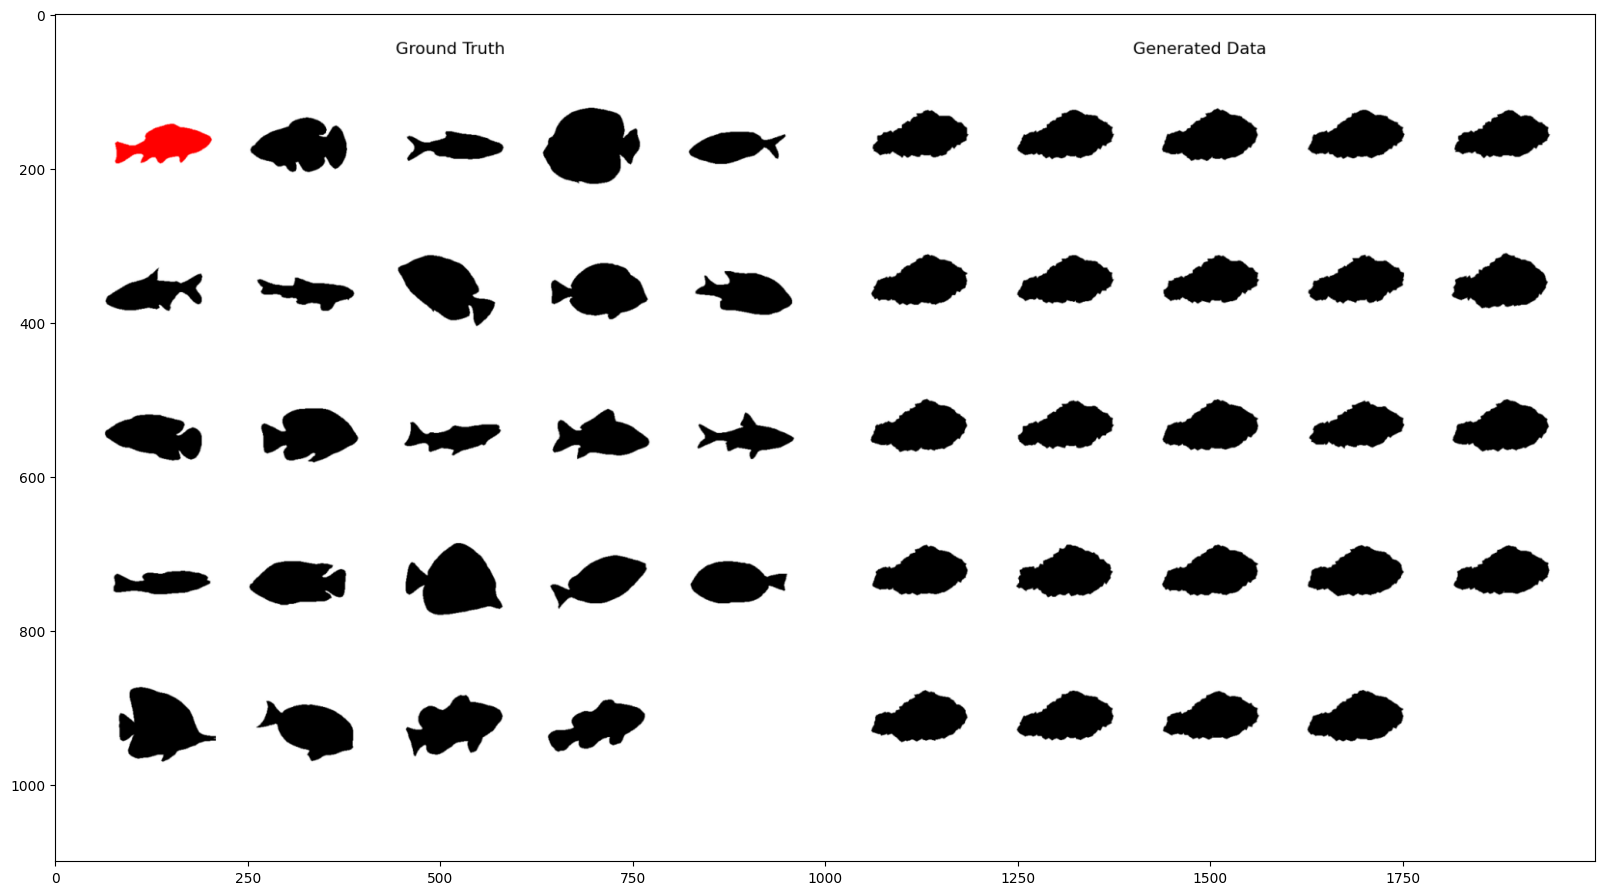

In [6]:
# from utils.generate import generate_data

ref_num = 0
var = 0.2
mu, log_var = model.encode(input_tensor.to(DEVICE, dtype=torch.float64).view(n, INPUT_DIM))
z_ground_truth = mu + log_var.exp().sqrt()
mu_vals = torch.repeat_interleave(z_ground_truth[ref_num].view(1, -1), n, dim=0)
generated_contour, z_generated = generate_data(
    model, num=n, mu_vals=mu_vals, k=var
)
generated_contour = generated_contour.detach().cpu().numpy()

visualize_latent_space(z_ground_truth, z_generated)


generated_images = [contour_to_binary(contour) for contour in generated_contour]
ground_truth_images = [contour_to_binary(contour, color=(255,0,0) if i == ref_num else (0, 0, 0)) for i, contour in enumerate(ground_truth_contour)]

ground_truth_grid = make_grid(ground_truth_images, rows=5, title='Ground Truth', figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title='Generated Data', figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 11))
plt.imshow(combined_grid)